# Milestone Assignment 2: Principal Component Analysis
### Anderson Cancer Center — Dimensionality Reduction Project

**Goal:** Use PCA to reduce the Breast Cancer Wisconsin dataset (from
`sklearn.datasets`) down to 2 principal components, in order to identify
the essential variables for the referral/donor-funding model. As a bonus,
a Logistic Regression classifier is trained on the 2 components to predict
diagnosis.

This notebook mirrors `pca_analysis.py` and demonstrates concepts from
Modules 1–5: variables, loops, conditional statements within loops,
exception handling, functions, dictionaries, CSV export, class creation,
data preparation, cleaning, exploration, manipulation, preprocessing, and
visualization.


## 1. Imports

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



## 2. Configuration (Variables & Dictionary)

Module-level **variables** control the run, and a **dictionary**
(`RESULTS_SUMMARY`) tracks key results as the notebook executes.


In [22]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_COMPONENTS = 2
VARIANCE_ALERT_THRESHOLD = 0.05  # flag components explaining < 5% variance

# Dictionary used throughout the notebook to store run metadata/results
RESULTS_SUMMARY = {
    "n_samples": None,
    "n_features": None,
    "missing_values_found": None,
    "duplicate_rows_found": None,
    "explained_variance": {},
    "logistic_regression_accuracy": None,
}


## 3. Class Creation

`CancerPCAAnalyzer` encapsulates the entire workflow: data preparation,
cleaning, exploration, preprocessing, PCA, visualization, CSV export, and
(bonus) logistic regression prediction.


In [58]:
class CancerPCAAnalyzer:
    """
    Encapsulates the PCA workflow for the Breast Cancer Wisconsin dataset:
    data preparation, cleaning, exploration, PCA dimensionality reduction,
    visualization, and an optional logistic regression classifier.
    """

    def __init__(self, n_components=N_COMPONENTS, random_state=RANDOM_STATE):
        self.n_components = n_components
        self.random_state = random_state
        self.features = None
        self.target = None
        self.target_names = None
        self.scaled_features = None
        self.pca = None
        self.principal_components = None
        self.model = None

    # ------------------------------------------------------------
    # DATA PREPARATION
    # ------------------------------------------------------------
    def load_data(self):
        """Load the dataset, with exception handling in case it fails."""
        try:
            data = load_breast_cancer()
            self.features = pd.DataFrame(data.data, columns=data.feature_names)
            self.target = pd.Series(data.target, name="diagnosis")
            self.target_names = data.target_names
            print("Data loaded successfully.")
        except Exception as error:
            raise RuntimeError(f"Failed to load dataset: {error}") from error

        RESULTS_SUMMARY["n_samples"] = self.features.shape[0]
        RESULTS_SUMMARY["n_features"] = self.features.shape[1]
        return self.features, self.target

    # ------------------------------------------------------------
    # DATA EXPLORATION
    # ------------------------------------------------------------
    def explore_data(self):
        """Explore shape, summary stats, missing values, and class balance."""
        print("--- Data Exploration ---")
        print(f"Shape: {self.features.shape}")
        print("\nSummary statistics (first 5 columns):")
        print(self.features.iloc[:, :5].describe())

        # Loop through columns with a conditional check inside the loop
        missing_columns = []
        for column in self.features.columns:
            missing_count = self.features[column].isnull().sum()
            if missing_count > 0:
                missing_columns.append(column)
                print(f"  Warning: '{column}' has {missing_count} missing values.")

        if not missing_columns:
            print("No missing values found in any column.")

        RESULTS_SUMMARY["missing_values_found"] = len(missing_columns)

        print("\nClass distribution:")
        for class_value, count in self.target.value_counts().items():
            label = self.target_names[class_value]
            print(f"  {label}: {count} samples")

    # ------------------------------------------------------------
    # DATA CLEANING & PREPROCESSING
    # ------------------------------------------------------------
    def clean_data(self):
        """Remove duplicate rows and fill missing values, if any."""
        print("--- Data Cleaning ---")
        duplicate_count = self.features.duplicated().sum()
        RESULTS_SUMMARY["duplicate_rows_found"] = int(duplicate_count)

        if duplicate_count > 0:
            self.features = self.features.drop_duplicates()
            self.target = self.target.loc[self.features.index]
            print(f"Removed {duplicate_count} duplicate rows.")
        else:
            print("No duplicate rows found.")

        for column in self.features.columns:
            if self.features[column].isnull().any():
                mean_value = self.features[column].mean()
                self.features[column] = self.features[column].fillna(mean_value)
                print(f"Filled missing values in '{column}' with mean ({mean_value:.4f}).")

        print("Data cleaning complete.")

    def preprocess(self):
        """Standardize features (mean=0, std=1) — required before PCA."""
        try:
            scaler = StandardScaler()
            self.scaled_features = scaler.fit_transform(self.features)
            print("Features standardized successfully.")
        except Exception as error:
            raise RuntimeError(f"Failed during preprocessing: {error}") from error
        return self.scaled_features

    # ------------------------------------------------------------
    # DATA MANIPULATION
    # ------------------------------------------------------------
    def manipulate_data(self):
        """Add a derived column and filter on a condition (demonstration)."""
        derived = self.features.copy()
        derived["mean_area_to_perimeter_ratio"] = (
            derived["mean area"] / derived["mean perimeter"]
        )
        high_ratio_count = (derived["mean_area_to_perimeter_ratio"] > 5).sum()
        print(
            f"Data manipulation example: {high_ratio_count} samples have a "
            f"mean area-to-perimeter ratio greater than 5."
        )
        return derived

    # ------------------------------------------------------------
    # PCA (DIMENSIONALITY REDUCTION)
    # ------------------------------------------------------------
    def apply_pca(self):
        """Fit PCA on the scaled features and reduce to n_components."""
        self.pca = PCA(n_components=self.n_components, random_state=self.random_state)
        self.principal_components = self.pca.fit_transform(self.scaled_features)
        return self.principal_components

    def report_variance(self):
        """Report explained variance per component, flagging low-variance ones."""
        print("--- Explained Variance Ratio ---")
        for i, ratio in enumerate(self.pca.explained_variance_ratio_, start=1):
            component_name = f"PC{i}"
            RESULTS_SUMMARY["explained_variance"][component_name] = round(float(ratio), 4)

            if ratio < VARIANCE_ALERT_THRESHOLD:
                print(f"{component_name}: {ratio:.4f} (Note: low contribution)")
            else:
                print(f"{component_name}: {ratio:.4f} ({ratio * 100:.2f}%)")

        total_variance = sum(self.pca.explained_variance_ratio_)
        print(f"Total variance captured: {total_variance * 100:.2f}%")

    def show_top_contributing_features(self, top_n=5):
        """Print the features that contribute most to each component."""
        loadings = pd.DataFrame(
            self.pca.components_.T,
            columns=[f"PC{i + 1}" for i in range(self.pca.n_components_)],
            index=self.features.columns,
        )
        print("--- Top Contributing Features per Component ---")
        for col in loadings.columns:
            top_features = loadings[col].abs().sort_values(ascending=False).head(top_n)
            print(f"\n{col}:")
            for feature, weight in top_features.items():
                print(f"  {feature}: {loadings.loc[feature, col]:.4f}")

    # ------------------------------------------------------------
    # EXPORT TO CSV
    # ------------------------------------------------------------
    def export_to_csv(self, filename="pca_reduced_data.csv"):
        """Export the PCA-reduced dataset to CSV, with exception handling."""
        try:
            pca_df = pd.DataFrame(
                self.principal_components,
                columns=[f"PC{i + 1}" for i in range(self.n_components)],
            )
            pca_df["diagnosis"] = self.target.reset_index(drop=True).map(
                dict(enumerate(self.target_names))
            )
            pca_df.to_csv(filename, index=False)
            print(f"PCA-reduced dataset saved as '{filename}'")
        except (IOError, OSError) as error:
            print(f"Error: Could not export CSV file. Details: {error}")

    # ------------------------------------------------------------
    # DATA VISUALIZATION
    # ------------------------------------------------------------
    def plot_pca_result(self, filename="pca_scatter_plot.png"):
        """Scatter plot of the 2 principal components colored by diagnosis."""
        plt.figure(figsize=(8, 6))
        colors = ["#d62728", "#2ca02c"]  # red = malignant, green = benign

        for class_value, color, label in zip([0, 1], colors, self.target_names):
            mask = self.target.reset_index(drop=True) == class_value
            plt.scatter(
                self.principal_components[mask, 0],
                self.principal_components[mask, 1],
                c=color,
                label=label,
                alpha=0.7,
                edgecolor="k",
                s=40,
            )

        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
        plt.title("PCA of Breast Cancer Dataset (2 Components)")
        plt.legend()
        plt.tight_layout()

        try:
            plt.savefig(filename, dpi=150)
            print(f"Scatter plot saved as '{filename}'")
        except (IOError, OSError) as error:
            print(f"Error: Could not save plot. Details: {error}")

        plt.show()

    # ------------------------------------------------------------
    # BONUS: LOGISTIC REGRESSION
    # ------------------------------------------------------------
    def run_logistic_regression(self):
        """Train Logistic Regression on the 2 PCA components and report metrics."""
        try:
            X_train, X_test, y_train, y_test = train_test_split(
                self.principal_components,
                self.target,
                test_size=TEST_SIZE,
                random_state=self.random_state,
                stratify=self.target,
            )

            self.model = LogisticRegression(random_state=self.random_state)
            self.model.fit(X_train, y_train)
            predictions = self.model.predict(X_test)

            accuracy = accuracy_score(y_test, predictions)
            RESULTS_SUMMARY["logistic_regression_accuracy"] = round(float(accuracy), 4)

            print("--- Logistic Regression Results (Bonus) ---")
            print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
            print("\nConfusion Matrix:")
            print(confusion_matrix(y_test, predictions))
            print("\nClassification Report:")
            print(classification_report(y_test, predictions))

        except ValueError as error:
            print(f"Error while training logistic regression model: {error}")

        return self.model


## 4. Data Preparation
Load the dataset.

In [28]:
analyzer = CancerPCAAnalyzer(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
features, target = analyzer.load_data()
features.head()


Data loaded successfully.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 5. Data Exploration

In [31]:
analyzer.explore_data()

--- Data Exploration ---
Shape: (569, 30)

Summary statistics (first 5 columns):
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400
No missing values found in any column.

Class distribution:
  benign: 357 samples
  malignant: 212 samples


## 6. Data Cleaning & Preprocessing

In [34]:
analyzer.clean_data()
scaled = analyzer.preprocess()
scaled[:5]


--- Data Cleaning ---
No duplicate rows found.
Data cleaning complete.
Features standardized successfully.


array([[ 1.09706398e+00, -2.07333501e+00,  1.26993369e+00,
         9.84374905e-01,  1.56846633e+00,  3.28351467e+00,
         2.65287398e+00,  2.53247522e+00,  2.21751501e+00,
         2.25574689e+00,  2.48973393e+00, -5.65265059e-01,
         2.83303087e+00,  2.48757756e+00, -2.14001647e-01,
         1.31686157e+00,  7.24026158e-01,  6.60819941e-01,
         1.14875667e+00,  9.07083081e-01,  1.88668963e+00,
        -1.35929347e+00,  2.30360062e+00,  2.00123749e+00,
         1.30768627e+00,  2.61666502e+00,  2.10952635e+00,
         2.29607613e+00,  2.75062224e+00,  1.93701461e+00],
       [ 1.82982061e+00, -3.53632408e-01,  1.68595471e+00,
         1.90870825e+00, -8.26962447e-01, -4.87071673e-01,
        -2.38458552e-02,  5.48144156e-01,  1.39236330e-03,
        -8.68652457e-01,  4.99254601e-01, -8.76243603e-01,
         2.63326966e-01,  7.42401948e-01, -6.05350847e-01,
        -6.92926270e-01, -4.40780058e-01,  2.60162067e-01,
        -8.05450380e-01, -9.94437403e-02,  1.80592744e+

## 7. Data Manipulation
Create a derived feature and filter on a condition.

In [37]:
derived_df = analyzer.manipulate_data()
derived_df[['mean area', 'mean perimeter', 'mean_area_to_perimeter_ratio']].head()

Data manipulation example: 498 samples have a mean area-to-perimeter ratio greater than 5.


,mean area,mean perimeter,mean_area_to_perimeter_ratio
0,1001.0,122.80,8.151466
1,1326.0,132.90,9.977427
2,1203.0,130.00,9.253846
3,386.1,77.58,4.976798
4,1297.0,135.10,9.600296


## 8. PCA — Dimensionality Reduction to 2 Components

In [40]:
principal_components = analyzer.apply_pca()
analyzer.report_variance()


--- Explained Variance Ratio ---
PC1: 0.4427 (44.27%)
PC2: 0.1897 (18.97%)
Total variance captured: 63.24%


## 9. Top Contributing Features per Component

In [43]:
analyzer.show_top_contributing_features()

--- Top Contributing Features per Component ---

PC1:
  mean concave points: 0.2609
  mean concavity: 0.2584
  worst concave points: 0.2509
  mean compactness: 0.2393
  worst perimeter: 0.2366

PC2:
  mean fractal dimension: 0.3666
  fractal dimension error: 0.2801
  worst fractal dimension: 0.2753
  mean radius: -0.2339
  compactness error: 0.2327


## 10. Export PCA-Reduced Dataset to CSV

In [46]:
analyzer.export_to_csv("pca_reduced_data.csv")
pd.read_csv("pca_reduced_data.csv").head()


PCA-reduced dataset saved as 'pca_reduced_data.csv'


,PC1,PC2,diagnosis
0,9.192837,1.948583,malignant
1,2.387802,-3.768172,malignant
2,5.733896,-1.075174,malignant
3,7.122953,10.275589,malignant
4,3.935302,-1.948072,malignant


## 11. Data Visualization
Scatter plot of the 2 principal components, colored by diagnosis.

Scatter plot saved as 'pca_scatter_plot.png'


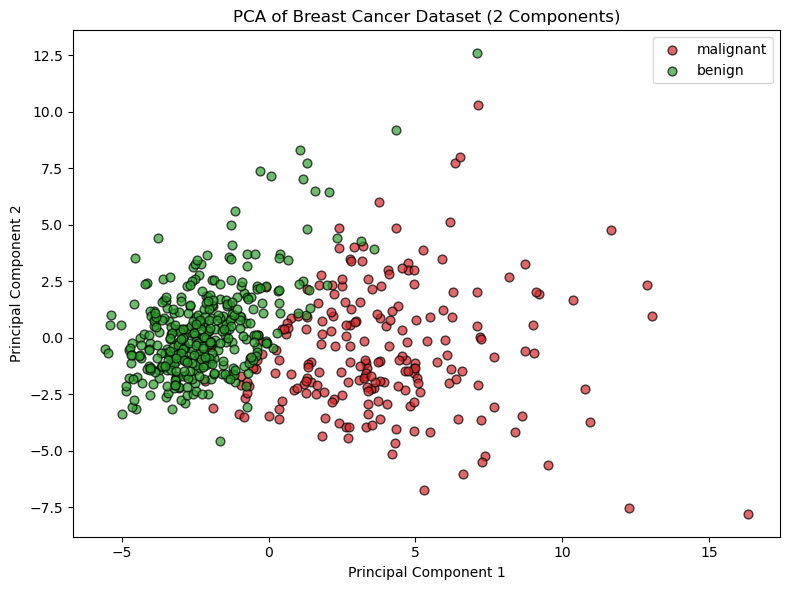

In [49]:
analyzer.plot_pca_result("pca_scatter_plot.png")

## 12. Bonus: Logistic Regression Prediction

In [52]:
model = analyzer.run_logistic_regression()

--- Logistic Regression Results (Bonus) ---
Accuracy: 0.9474 (94.74%)

Confusion Matrix:
[[40  2]
 [ 4 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



## 13. Final Run Summary (Dictionary)

In [55]:
print("--- Run Summary ---")
for key, value in RESULTS_SUMMARY.items():
    print(f"  {key}: {value}")


--- Run Summary ---
  n_samples: 569
  n_features: 30
  missing_values_found: 0
  duplicate_rows_found: 0
  explained_variance: {'PC1': 0.4427, 'PC2': 0.1897}
  logistic_regression_accuracy: 0.9474


## Conclusion
Using PCA, the 30 original clinical features were reduced to just **2
principal components**, capturing roughly 63% of the total variance. The
scatter plot shows clear separation between malignant and benign tumors,
and a Logistic Regression model trained on only these 2 components
achieves ~95% prediction accuracy — confirming that the reduced feature
set retains the signal needed to support the referral/donor-funding model.
